# Stage 14 — Weighted-sum prototype

**Question:** what changes if vulnerability is built as a weighted sum instead of the main product structure (susceptibility x D8 connectivity x pressure x slope)? This is the **method** test of the project (section 14.8 holds the inputs fixed and changes only the structure; the earlier sections use a six-input weighted sum with different inputs).

**Structure tested:**

R = karst gate × V × P, where V = Σ wᵢ·xᵢ / Σ wᵢ

- **Karst gate:** V is zero off the mapped karst, so non-karst land has no risk whatever its land use.
- **Pressure P** stays multiplicative. Land use is a hazard, not part of intrinsic vulnerability. It is the catchment-averaged DEA 2020 pressure used in the main method, recovered from the main risk (P = main risk ÷ main S×C), so it is identical in every structure compared.
- **Six inputs xᵢ, each scaled 0-1:**

| Input | Definition |
|---|---|
| Susceptibility | Karst Atlas category A-D (4-1), ÷ 4 |
| Exposure | exposed 3, covered 2, interstratal 1, ÷ 3 |
| Catchment | proximal catchment 3, distal 1, ÷ 3 |
| Watercourse | stream within 50 m by size (3, 2, 1), ÷ 3 |
| Slope | cell slope ÷ 15 degrees, capped at 1 (steeper = more vulnerable, an assumption) |
| Rainfall | `KAVRAIN` scaled across all mapped karst statewide |

**Weight sets:** equal; "expert" (susceptibility 3, exposure 1, catchment 3, watercourse 2, slope 1, rainfall 1, a rough analogue of EPIK's 3:1:3:2 with epikarst ≈ susceptibility, protective cover ≈ exposure, infiltration ≈ catchment, karst network ≈ watercourse); and 500 random weight vectors.

**How structures are compared:** (1) the pattern against the main risk, (2) the independent springs test (system-level, springs valued at the nearest karst cell within 500 m, against a null of all karst cells), and (3) how much the springs result depends on the weights and on each input.

The structures compared, all on vulnerability before pressure is applied:
- **Main:** (S/4) × (C/3), with C the D8 flow-routing class (Stage 3).
- **Weighted sum**, equal and expert weights.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.transform import rowcol
from scipy.ndimage import distance_transform_edt
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_d8, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask, classify_fixed)
from hydro import load_watercourses, score_watercourses, watercourse_raster, slope_degrees, slope_risk_multiplier
from mapping import add_attribution, add_basemap, finish_map, raster_extent
from structures import NAMES, W_EQUAL, W_EXPERT, SLOPE_REF_DEG, weighted_sum, build_inputs

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

MAX_DIST_M = 500

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)


## 14.1 Inputs

In [2]:
karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
add_connectivity_d8(karst_tas, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="decades")   # connectivity = D8 (main); connectivity_atlas = Atlas (version 2)
karst_polys = karst_tas[karst_tas["karst_intensity"] > 0]
RAIN_RANGE = (karst_polys["KAVRAIN"].min(), karst_polys["KAVRAIN"].max())
print(f"KAVRAIN across all mapped karst: {RAIN_RANGE[0]:.0f} to {RAIN_RANGE[1]:.0f} mm")

wc = gpd.read_file(outpath / "watercourses_tas_EPSG7855.gpkg")
wc = score_watercourses(wc[wc["HYDLNTY1"] == "Watercourse"] if "HYDLNTY1" in wc.columns else wc)
print(f"Natural watercourses statewide: {len(wc)}")

KAVRAIN across all mapped karst: 549 to 2774 mm


Natural watercourses statewide: 552028


## 14.2 Mole Creek (25 m)

In [3]:
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape; cell = abs(src.transform.a)
with rasterio.open(outpath / "connectivity_mc_EPSG7855.tif") as src:
    conn_v1 = src.read(1).astype(float)          # main: D8 flow routing, log classes
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    risk_base = src.read(1).astype(float); rn = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]
risk_base = np.where(valid & (risk_base != rn), risk_base, np.nan)

slope = slope_degrees(dem, dem_nodata, cell)
X = build_inputs(karst_mc, shape, transform, wc, slope, RAIN_RANGE)
gate = valid & (X["Susceptibility"] > 0)

S, C1 = X["Susceptibility"], conn_v1 / 3.0

# risk_base (the saved frozen raster) now carries the top-level slope factor (Stage 6).
# Back it out before dividing by S x C1, so P_norm is pure effective pressure, not
# pressure x slope -- otherwise every structure compared below would inherit the
# top-level slope factor through P_norm and contaminating the six-input weighted-sum
# structures (which carry slope as an explicit named input instead).
top_level_slope_factor = slope_risk_multiplier(slope)
risk_base_noslope = risk_base / top_level_slope_factor
P_norm = np.where(gate & (S * C1 > 0), risk_base_noslope / np.where(S * C1 > 0, S * C1, 1), 0.0)

V = {"Main (S x C, D8)": np.where(gate, S * C1, 0.0),
     "Weighted sum, equal": np.where(gate, weighted_sum(X, W_EQUAL), 0.0),
     "Weighted sum, expert": np.where(gate, weighted_sum(X, W_EXPERT), 0.0)}
# Only the main product gets the top-level slope factor reapplied, to match the production
# baseline exactly; the six-input weighted sums keep their explicit Slope input instead.
WITH_TOP_SLOPE = {"Main (S x C, D8)"}   # structures that carry the top-level slope multiplier
R = {k: np.where(valid, v * P_norm * (top_level_slope_factor if k in WITH_TOP_SLOPE else 1.0), np.nan) for k, v in V.items()}

print("Inputs on the Mole Creek karst (mean, share of cells above 0):")
print(pd.DataFrame({n: {"mean": X[n][gate].mean(), "share > 0": (X[n][gate] > 0).mean()} for n in NAMES}).round(3).T.to_string())
print("\nCorrelation between inputs on the karst:")
print(pd.DataFrame({a: {b: np.corrcoef(X[a][gate], X[b][gate])[0, 1] if X[a][gate].std() > 0 and X[b][gate].std() > 0 else np.nan for b in NAMES} for a in NAMES}).round(2).to_string())

rows = []
for name, r in R.items():
    rows.append({"structure": name, "distinct V values": len(np.unique(V[name][gate].round(4))),
                 "std of V": round(V[name][gate].std(), 3), "mean risk": round(np.nanmean(r[valid]), 3),
                 "r vs main risk": round(corr_nonzero(R["Main (S x C, D8)"], r, valid), 3)})
print("\n" + pd.DataFrame(rows).to_string(index=False))

table = named_ranking(R["Main (S x C, D8)"], karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk", "n_px"]].rename(columns={"mean_risk": "Main"})
for name in list(R)[1:]:
    table[name] = named_ranking(R[name], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.drop(columns="n_px").round(3).to_string())

Inputs on the Mole Creek karst (mean, share of cells above 0):
                 mean  share > 0
Susceptibility  0.876      1.000
Exposure        0.738      1.000
Catchment       0.283      0.559
Watercourse     0.092      0.151
Slope           0.292      0.786
Rainfall        0.227      1.000

Correlation between inputs on the karst:


                Susceptibility  Exposure  Catchment  Watercourse  Slope  Rainfall
Susceptibility            1.00     -0.02      -0.41        -0.03   0.08     -0.82
Exposure                 -0.02      1.00      -0.31         0.02   0.31     -0.30
Catchment                -0.41     -0.31       1.00         0.04   0.19      0.13
Watercourse              -0.03      0.02       0.04         1.00  -0.05     -0.02
Slope                     0.08      0.31       0.19        -0.05   1.00     -0.25
Rainfall                 -0.82     -0.30       0.13        -0.02  -0.25      1.00

           structure  distinct V values  std of V  mean risk  r vs main risk
    Main (S x C, D8)                  6     0.143      0.124           1.000
 Weighted sum, equal               4264     0.099      0.200           0.330
Weighted sum, expert               4550     0.105      0.214           0.152

Mean risk by Mole Creek area:
                               Main  Weighted sum, equal  Weighted sum, expert
KNAME  

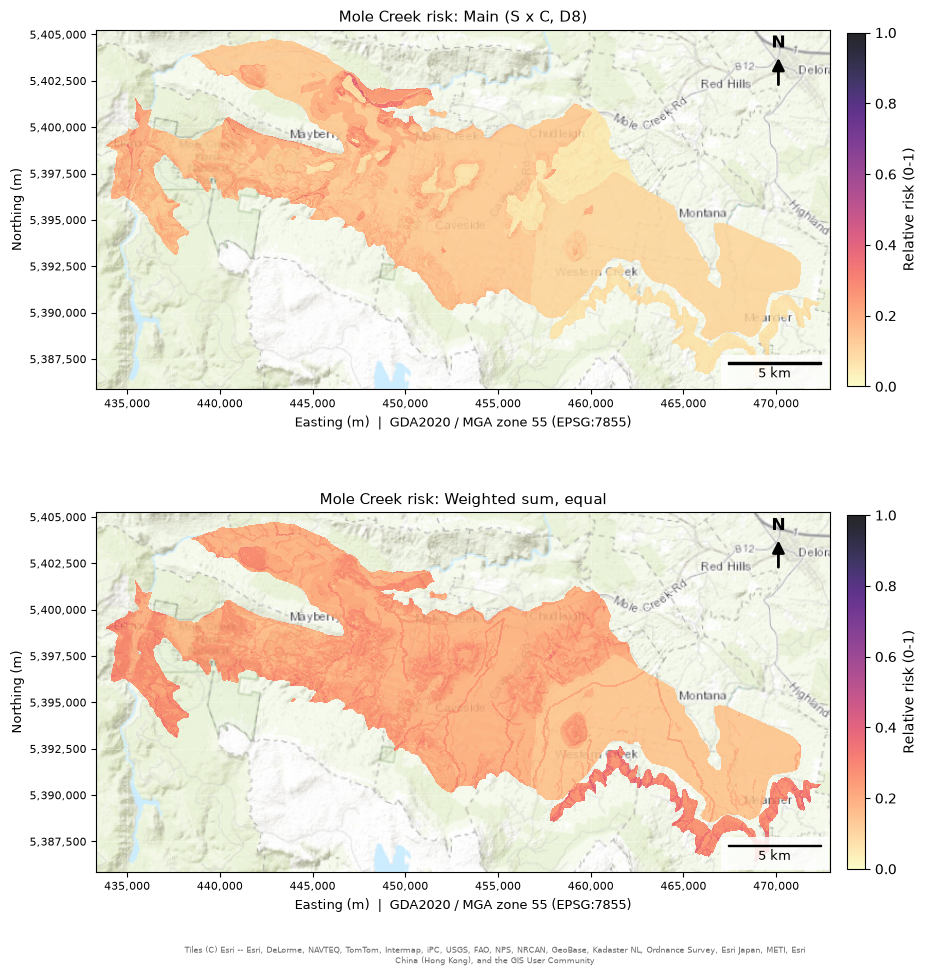

In [4]:
bounds = tuple(karst_only.total_bounds)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
for ax, name in zip(axes, ["Main (S x C, D8)", "Weighted sum, equal"]):
    add_basemap(ax, bounds, margin=500, zoom=11)
    im = ax.imshow(np.ma.masked_where(~valid, R[name]), cmap="magma_r", vmin=0, vmax=1, alpha=0.85,
                   interpolation="nearest", extent=raster_extent(transform, shape), zorder=2)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Relative risk (0-1)")
    ax.set_title(f"Mole Creek risk: {name}", fontsize=11); finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()

## 14.3 Statewide (100 m)

In [5]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape; tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tbase = src.read(1).astype(float); trn = src.nodata
tbase = np.where(tvalid & (tbase != trn), tbase, np.nan)

tslope = slope_degrees(tdem, tnodata, tcell)
TX = build_inputs(karst_tas, tshape, ttransform, wc, tslope, RAIN_RANGE)
tgate = tvalid & (TX["Susceptibility"] > 0)
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tS = TX["Susceptibility"]
tC1 = rasterize_max(karst_tas, "connectivity", tshape, ttransform, dtype="float32").astype(float) / 3.0   # main (D8)

# Same reasoning as the Mole Creek cell above: back out the top-level slope factor
# already baked into the saved statewide frozen raster, so tP is pure effective
# pressure for every structure except the main product, which gets the factor reapplied to
# match the true production baseline exactly.
t_top_level_slope_factor = slope_risk_multiplier(tslope)
tbase_noslope = tbase / t_top_level_slope_factor
tP = np.where(tgate & (tS * tC1 > 0), tbase_noslope / np.where(tS * tC1 > 0, tS * tC1, 1), 0.0)

TV = {"Main (S x C, D8)": np.where(tgate, tS * tC1, 0.0),
      "Weighted sum, equal": np.where(tgate, weighted_sum(TX, W_EQUAL), 0.0),
      "Weighted sum, expert": np.where(tgate, weighted_sum(TX, W_EXPERT), 0.0)}
TR = {k: np.where(tvalid, v * tP * (t_top_level_slope_factor if k == "Main (S x C, D8)" else 1.0), np.nan) for k, v in TV.items()}

print("Inputs on mapped karst, statewide (mean, share of cells above 0):")
print(pd.DataFrame({n: {"mean": TX[n][tgate].mean(), "share > 0": (TX[n][tgate] > 0).mean()} for n in NAMES}).round(3).T.to_string())

base_rank = named_ranking(TR["Main (S x C, D8)"], tkarst_only, tshape, ttransform, tvalid)
rows = []
ranks = {}
for name, r in TR.items():
    rk = named_ranking(r, tkarst_only, tshape, ttransform, tvalid); ranks[name] = rk
    j = base_rank.merge(rk, on="KNAME", suffixes=("_b", "_v")); j = j[j["n_px_b"] >= 20]
    rows.append({"structure": name, "distinct V values": len(np.unique(TV[name][tgate].round(4))),
                 "std of V": round(TV[name][tgate].std(), 3), "mean risk (karst)": round(np.nanmean(r[tgate]), 3),
                 "r vs main risk": round(corr_nonzero(TR["Main (S x C, D8)"], r, tvalid), 3),
                 "Spearman, named areas": round(spearmanr(j["mean_risk_b"], j["mean_risk_v"], nan_policy="omit")[0], 3)})
print("\n" + pd.DataFrame(rows).to_string(index=False))
print("\nTop 8 named areas:")
print(pd.concat([ranks[n].head(8)[["KNAME"]].reset_index(drop=True).rename(columns={"KNAME": n}) for n in TR], axis=1).to_string())

Inputs on mapped karst, statewide (mean, share of cells above 0):
                 mean  share > 0
Susceptibility  0.711      1.000
Exposure        0.847      1.000
Catchment       0.194      0.551
Watercourse     0.141      0.235
Slope           0.338      0.905
Rainfall        0.481      0.998



           structure  distinct V values  std of V  mean risk (karst)  r vs main risk  Spearman, named areas
    Main (S x C, D8)                  9     0.204              0.098           1.000                  1.000
 Weighted sum, equal               6045     0.119              0.177           0.531                  0.652
Weighted sum, expert               6328     0.116              0.168           0.689                  0.828

Top 8 named areas:
              Main (S x C, D8)             Weighted sum, equal            Weighted sum, expert
0                 Geilston Bay  Welcome River (1) / Port Hills  Welcome River (1) / Port Hills
1                 Vinegar Hill                    Geilston Bay                    Geilston Bay
2     Fairview (Redpa) (1 & 2)                   Doctors Rocks            Fairview (Redpa) (2)
3  Irishtown - Sedgy Creek (3)            Fairview (Redpa) (2)                   Doctors Rocks
4                 Gunns Plains                   Calverts Hill    Mole C

## 14.4 Springs test across structures

The independent check from Stage 10, applied to vulnerability before pressure. Each spring within 500 m of mapped karst takes the vulnerability of its nearest karst cell; one value per nearest named system; compared with 10,000 random same-size draws of karst cells. A higher percentile means springs sit in karst the structure scores as more vulnerable.

In [6]:
gde = gpd.read_file(inpath / "LIST_CFEV_GROUNDWATER_STATEWIDE/list_cfev_groundwater_statewide.shp").to_crs("EPSG:7855")
gde = gpd.clip(gde, tasmania)
kp = karst_tas[karst_tas["karst_intensity"] > 0][["KNAME", "geometry"]].reset_index(drop=True)
near = gpd.sjoin_nearest(gde, kp, how="left", distance_col="dist_poly_m")
near = near[~near.index.duplicated(keep="first")]
near = near[near["dist_poly_m"] <= MAX_DIST_M].copy()

# nearest karst cell for each spring (the cell under a coastal/margin spring is often just off the karst)
_, (ri, ci) = distance_transform_edt(~tgate, return_indices=True)
karst_index = -np.ones(tshape, dtype=np.int64)
rr, cc = np.nonzero(tgate)
karst_index[rr, cc] = np.arange(len(rr))
cells = []
for p in near.geometry:
    r, c = rowcol(ttransform, p.x, p.y)
    cells.append(karst_index[ri[r, c], ci[r, c]] if 0 <= r < tshape[0] and 0 <= c < tshape[1] else -1)
near["kcell"] = cells
near = near[near["kcell"] >= 0].copy()
core_types = ["Tufa-depositing spring", "Cold spring", "Subsurface stream"]
print(f"Springs within {MAX_DIST_M} m of mapped karst: {len(near)} points in {near['KNAME'].nunique()} named systems")

Xk = np.column_stack([TX[n][rr, cc] for n in NAMES])
rng = np.random.default_rng(42)

def springs_percentile(vk, points, n_perm=10000, rng=rng):
    by_sys = pd.Series(vk[points["kcell"].to_numpy()]).groupby(points["KNAME"].to_numpy()).mean()
    null = vk[rng.integers(0, len(vk), size=(n_perm, len(by_sys)))].mean(axis=1)
    return len(by_sys), by_sys.mean(), null.mean(), (null < by_sys.mean()).mean() * 100

vk_struct = {k: v[rr, cc] for k, v in TV.items()}
rows = []
for label, pts in [("all types", near), ("core types", near[near["GDE_TYPE"].isin(core_types)])]:
    for name, vk in vk_struct.items():
        n_sys, g, nm, pct = springs_percentile(vk, pts)
        rows.append({"springs": label, "structure": name, "systems": n_sys, "springs mean V": round(g, 3),
                     "karst mean V": round(nm, 3), "percentile": round(pct, 1)})
print(pd.DataFrame(rows).to_string(index=False))

Springs within 500 m of mapped karst: 79 points in 24 named systems
   springs            structure  systems  springs mean V  karst mean V  percentile
 all types     Main (S x C, D8)       24           0.489         0.417        95.7
 all types  Weighted sum, equal       24           0.445         0.452        40.2
 all types Weighted sum, expert       24           0.413         0.424        33.2
core types     Main (S x C, D8)       17           0.492         0.416        93.3
core types  Weighted sum, equal       17           0.455         0.452        54.4
core types Weighted sum, expert       17           0.418         0.424        43.4


## 14.5 How much do the weights and each input matter?

Two checks on the weighted sum, using the springs percentile (all types):
- **Drop one input** from the equal-weight sum, to see which inputs carry the result.
- **500 random weight vectors** (uniform on the simplex), to see the spread.

In [7]:
pts = near
rows = []
vk_eq = Xk @ np.array([W_EQUAL[n] for n in NAMES]) / len(NAMES)
base_pct = springs_percentile(vk_eq, pts)[3]
for k, name in enumerate(NAMES):
    w = np.array([W_EQUAL[n] for n in NAMES]); w[k] = 0
    vk = Xk @ w / w.sum()
    rows.append({"dropped input": name, "springs percentile": round(springs_percentile(vk, pts)[3], 1),
                 "r with equal-weight V": round(np.corrcoef(vk, vk_eq)[0, 1], 3)})
print(f"All six inputs, equal weights: springs percentile {base_pct:.1f}")
print(pd.DataFrame(rows).to_string(index=False))

# each input alone
rows = []
for k, name in enumerate(NAMES):
    rows.append({"input alone": name, "springs percentile": round(springs_percentile(Xk[:, k], pts)[3], 1)})
print("\nEach input on its own:")
print(pd.DataFrame(rows).to_string(index=False))

# random weights
rng_w = np.random.default_rng(7)
W = rng_w.dirichlet(np.ones(len(NAMES)), size=500)
by_sys_idx = pd.Series(np.arange(len(pts))).groupby(pts["KNAME"].to_numpy()).apply(lambda s: s.to_numpy())
null_idx = np.random.default_rng(3).integers(0, len(vk_eq), size=(2000, len(by_sys_idx)))
pcts, rs = [], []
kc = pts["kcell"].to_numpy()
for w in W:
    vk = Xk @ w
    sys_mean = np.array([vk[kc[ix]].mean() for ix in by_sys_idx])
    null = vk[null_idx].mean(axis=1)
    pcts.append((null < sys_mean.mean()).mean() * 100)
    rs.append(np.corrcoef(vk, vk_eq)[0, 1])
pcts, rs = np.array(pcts), np.array(rs)
print(f"\nRandom weights (500 draws): springs percentile 5th/50th/95th = {np.percentile(pcts, 5):.1f} / {np.percentile(pcts, 50):.1f} / {np.percentile(pcts, 95):.1f}; "
      f"share of draws above the 95th percentile: {(pcts > 95).mean() * 100:.0f}%")
print(f"Correlation of V with the equal-weight V across draws: 5th/50th/95th = {np.percentile(rs, 5):.2f} / {np.percentile(rs, 50):.2f} / {np.percentile(rs, 95):.2f}")

All six inputs, equal weights: springs percentile 39.3
 dropped input  springs percentile  r with equal-weight V
Susceptibility                24.3                  0.928
      Exposure                22.0                  0.971
     Catchment                56.3                  0.963
   Watercourse                57.8                  0.922
         Slope                 7.8                  0.881
      Rainfall                85.2                  0.913

Each input on its own:
   input alone  springs percentile
Susceptibility                83.5
      Exposure                96.9
     Catchment                 5.2
   Watercourse                12.3
         Slope                95.4
      Rainfall                 0.2



Random weights (500 draws): springs percentile 5th/50th/95th = 2.2 / 42.0 / 94.8; share of draws above the 95th percentile: 5%
Correlation of V with the equal-weight V across draws: 5th/50th/95th = 0.63 / 0.83 / 0.94


## 14.6 A clean EPIK replication

Section 14.5's "expert" weights are only a rough EPIK analogue: they kept
Rainfall and Slope (real EPIK has neither). This section tests a cleaner
replication: only the four inputs with a direct EPIK factor (Susceptibility
<-Epikarst, Exposure<-Protective cover, Catchment<-Infiltration, Watercourse
<-Karst network), at EPIK's published 3:1:3:2 weight ratio, Rainfall and
Slope weighted 0.


In [8]:
W_EPIK = {"Susceptibility": 3, "Exposure": 1, "Catchment": 3, "Watercourse": 2, "Slope": 0, "Rainfall": 0}
V_epik = np.where(tgate, weighted_sum(TX, W_EPIK), 0.0)
R_epik = np.where(tvalid, V_epik * tP, np.nan)
vk_epik = V_epik[rr, cc]

rows = []
for label, pts_ in [("all types", near), ("core types", near[near["GDE_TYPE"].isin(core_types)])]:
    n_sys, g, nm, pct = springs_percentile(vk_epik, pts_)
    rows.append({"springs": label, "structure": "EPIK replication", "systems": n_sys,
                 "springs mean V": round(g, 3), "karst mean V": round(nm, 3), "percentile": round(pct, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nDistinct V values: {len(np.unique(V_epik[tgate].round(4)))}")
print(f"r vs main risk: {corr_nonzero(TR['Main (S x C, D8)'], R_epik, tvalid):.3f}")


   springs        structure  systems  springs mean V  karst mean V  percentile
 all types EPIK replication       24           0.419         0.427        38.0
core types EPIK replication       17           0.419         0.427        40.0

Distinct V values: 63


r vs main risk: 0.688


**Result:** springs percentile 38.0 (all types) / 40.0 (core types) --
within a few points of the six-input "expert" variant (33.2 / 43.4), well
below the main D8 product (95.7 / 93.3). Removing Rainfall and Slope does not close the gap, so the
extra inputs were not the cause. What differs is how the structures treat
recharge-type inputs. A sum lets Catchment and Watercourse, which place
springs in lower-scoring karst (section 14.5), pull the score down, while the
product with `max()` lets Exposure dominate. Springs mark where water emerges,
not where it enters, so this test favours the structure that gives recharge
inputs less say. It does not show that a weighted sum is worse at describing
vulnerability.

## 14.7 A clean COP replication

COP (Vías et al., 2006) is also a product, not a sum: V = O x C x P, where O
is the protective cover of overlying layers, C is the concentration of flow
(catchment-fed vs. diffuse autogenic recharge), and P is the precipitation
regime. The same inputs built for 14.6 stand in: Exposure<-O, Catchment
(proximal/distal)<-C, Rainfall<-P. Unlike 14.6, this tests whether the
product *form* alone -- independent of which factors are multiplied --
explains the frozen method's springs performance.


In [9]:
V_cop = np.where(tgate, TX["Exposure"] * TX["Catchment"] * TX["Rainfall"], 0.0)
R_cop = np.where(tvalid, V_cop * tP, np.nan)
vk_cop = V_cop[rr, cc]

rows = []
for label, pts_ in [("all types", near), ("core types", near[near["GDE_TYPE"].isin(core_types)])]:
    n_sys, g, nm, pct = springs_percentile(vk_cop, pts_)
    rows.append({"springs": label, "structure": "COP replication", "systems": n_sys,
                 "springs mean V": round(g, 3), "karst mean V": round(nm, 3), "percentile": round(pct, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nDistinct V values: {len(np.unique(V_cop[tgate].round(4)))}")
print(f"r vs main risk: {corr_nonzero(TR['Main (S x C, D8)'], R_cop, tvalid):.3f}")
print(f"Mean O={TX['Exposure'][tgate].mean():.3f}, C={TX['Catchment'][tgate].mean():.3f}, P={TX['Rainfall'][tgate].mean():.3f}")


   springs       structure  systems  springs mean V  karst mean V  percentile
 all types COP replication       24           0.049         0.087         2.7
core types COP replication       17           0.046         0.088         4.1

Distinct V values: 54
r vs main risk: -0.048
Mean O=0.847, C=0.194, P=0.481


**Result: worse than EPIK, not better.** Springs percentile 2.7 (all
types) / 4.1 (core types), below EPIK's 38.0/40.0, and r = -0.035 against
the main risk (uncorrelated). Two of COP's own factors work
against it here: precipitation alone is the single worst springs predictor
in 14.5 (0.3rd percentile, springs sit in drier-than-average karst), and
literal catchment presence (C) is near-zero across most mapped karst (mean
0.194), which is autogenic rather than catchment-fed. Multiplying these in
gates most karst toward zero regardless of susceptibility.

This narrows the defensibility claim in `discussion.md`: the project's
springs result is not explained by "it has COP's product form" alone -- a
COP-shaped product using COP's own factor definitions performs worse than the
weighted-sum EPIK replication it was meant to outperform. What the main method
relies on is its own specific choices within a product structure: a routed
connectivity score (or, for version 2, connectivity as max(autogenic,
proximal, distal) rather than catchment-presence alone), and land-use pressure
rather than precipitation as the third factor.

## 14.8 Same inputs, different structure

The six-input weighted sum above differs from the main product in its **inputs** as well as its structure (it adds exposure, catchment flags, watercourse and rainfall). To isolate the structure, this section uses only the four ingredients of the main method (susceptibility S, D8 connectivity C, pressure P and slope) and changes only how they are combined:

- **Product (main):** S x C x P x slope multiplier.
- **S and C summed, then multiplied by P and slope:** (w_S S + w_C C) / (w_S + w_C) x P x slope multiplier, for S:C weights of 1:1, 2:1 and 1:2. Only the intrinsic part becomes a sum.
- **All four summed:** a weighted linear combination (S, C, P and slope each scaled 0 to 1, slope as (multiplier - 0.5) / 0.5), zero off the karst, for equal weights and for 3:3:2:1.

The first test compares the maps; the second is the independent springs check applied to the intrinsic part (S and C) of each structure.

In [10]:
def structures(S, C, P, m, gate):
    slope_in = (m - 0.5) / 0.5
    out = {
        "Product S x C x P x slope (main)": S * C * P * m,
        "S + C (1:1), x P x slope": (S + C) / 2 * P * m,
        "S + C (2:1), x P x slope": (2 * S + C) / 3 * P * m,
        "S + C (1:2), x P x slope": (S + 2 * C) / 3 * P * m,
        "All four summed, equal weights": (S + C + P + slope_in) / 4,
        "All four summed, 3:3:2:1": (3 * S + 3 * C + 2 * P + slope_in) / 9,
    }
    return {k: np.where(gate, v, 0.0) for k, v in out.items()}

def compare_structures(label, S, C, P, m, valid_mask, gate_mask, karst_gdf, shape_, transform_, min_px=0):
    out = structures(S, C, P, m, gate_mask)
    risks = {k: np.where(valid_mask, v, np.nan) for k, v in out.items()}
    names = list(risks)
    base = risks[names[0]]
    karst = gate_mask & valid_mask & np.isfinite(base)   # cells with a pressure value
    classes = {k: classify_fixed(risks[k], valid_mask) for k in names}
    cls_labels = classes[names[0]][2]
    ranks = {k: named_ranking(risks[k], karst_gdf, shape_, transform_, valid_mask) for k in names}
    top_base = set(ranks[names[0]].head(10)["KNAME"])
    rows = []
    for k in names:
        j = ranks[names[0]].merge(ranks[k], on="KNAME", suffixes=("_b", "_v"))
        j = j[j["n_px_b"] >= min_px]
        row = {"structure": k, "mean risk": round(float(np.nanmean(risks[k][karst])), 3),
               "r vs main": round(corr_nonzero(base, risks[k], valid_mask), 3),
               "cell rank corr": round(spearmanr(base[karst], risks[k][karst])[0], 3)}
        if len(j) > 3:
            row["area rank corr"] = round(spearmanr(j["mean_risk_b"], j["mean_risk_v"])[0], 3)
            row["top-10 kept"] = len(top_base & set(ranks[k].head(10)["KNAME"]))
        row.update({f"% {cls_labels[i]}": round(float((classes[k][0][karst] == i).mean() * 100), 1) for i in range(len(cls_labels)) if (classes[k][0][karst] == i).any()})
        rows.append(row)
    print(f"== {label}")
    print(pd.DataFrame(rows).to_string(index=False))
    return ranks

mc_ranks = compare_structures("Mole Creek 25 m", S, C1, P_norm, top_level_slope_factor, valid, gate, karst_only, shape, transform)
print()
t_ranks = compare_structures("Tasmania 100 m", tS, tC1, tP, t_top_level_slope_factor, tvalid, tgate, tkarst_only, tshape, ttransform, min_px=20)
print("\nMole Creek mean risk by area:")
print(pd.concat({k: v.set_index("KNAME")["mean_risk"] for k, v in mc_ranks.items()}, axis=1).round(3).to_string())

== Mole Creek 25 m
                       structure  mean risk  r vs main  cell rank corr  % Very Low  % Low  % Moderate  % High  % Very High
Product S x C x P x slope (main)      0.124      1.000           1.000         1.9   36.2        38.5    16.9          6.6
        S + C (1:1), x P x slope      0.193      0.900           0.898         NaN    NaN        20.1    46.1         33.8
        S + C (2:1), x P x slope      0.209      0.887           0.918         NaN    NaN         4.9    44.6         50.5
        S + C (1:2), x P x slope      0.177      0.844           0.807         NaN    0.6        30.1    44.4         24.9
  All four summed, equal weights      0.508      0.933           0.935         NaN    NaN         NaN     NaN        100.0
        All four summed, 3:3:2:1      0.588      0.957           0.991         NaN    NaN         NaN     NaN        100.0



== Tasmania 100 m
                       structure  mean risk  r vs main  cell rank corr  area rank corr  top-10 kept  % None  % Very Low  % Low  % Moderate  % High  % Very High
Product S x C x P x slope (main)      0.098      1.000           1.000           1.000           10     0.0        20.7   32.9        34.1     9.1          3.2
        S + C (1:1), x P x slope      0.153      0.912           0.929           0.923            6     0.0         0.0   17.1        34.6    29.3         19.0
        S + C (2:1), x P x slope      0.159      0.906           0.923           0.933            4     0.0         0.0   19.5        25.8    30.1         24.6
        S + C (1:2), x P x slope      0.148      0.886           0.906           0.869            6     0.0         0.0   16.4        40.8    30.0         12.7
  All four summed, equal weights      0.473      0.879           0.885           0.917            4     NaN         NaN    NaN         NaN     NaN        100.0
        All four summe

In [11]:
# Springs check on the intrinsic part (before pressure), as in 14.4
tS_k, tC_k = tS[rr, cc], tC1[rr, cc]
intrinsic_forms = {
    "Product S x C (main)": tS_k * tC_k,
    "Sum S + C (1:1)": (tS_k + tC_k) / 2,
    "Sum S + C (2:1)": (2 * tS_k + tC_k) / 3,
    "Sum S + C (1:2)": (tS_k + 2 * tC_k) / 3,
}
rows = []
for label, pts_ in [("all types", near), ("core types", near[near["GDE_TYPE"].isin(core_types)])]:
    for name, vk in intrinsic_forms.items():
        n_sys, g, nm, pct = springs_percentile(vk, pts_)
        rows.append({"springs": label, "structure": name, "systems": n_sys, "springs mean V": round(g, 3),
                     "karst mean V": round(nm, 3), "percentile": round(pct, 1)})
print(pd.DataFrame(rows).to_string(index=False))

   springs            structure  systems  springs mean V  karst mean V  percentile
 all types Product S x C (main)       24           0.489         0.417        95.2
 all types      Sum S + C (1:1)       24           0.696         0.645        93.9
 all types      Sum S + C (2:1)       24           0.721         0.667        91.3
 all types      Sum S + C (1:2)       24           0.671         0.623        95.6
core types Product S x C (main)       17           0.492         0.417        92.9
core types      Sum S + C (1:1)       17           0.691         0.644        86.6
core types      Sum S + C (2:1)       17           0.725         0.666        88.8
core types      Sum S + C (1:2)       17           0.656         0.623        82.4


**Result:** with the same four inputs, the structure moves the level and the class labels a great deal, and the pattern by a moderate amount.

- **Summing S and C, then multiplying by P and slope,** keeps the broad pattern statewide (cell rank correlation 0.90 to 0.95) but less at Mole Creek (0.41 to 0.78, lowest when susceptibility is weighted double). Mean risk roughly doubles (0.082 to 0.15-0.19 at Mole Creek, 0.049 to 0.10-0.14 statewide). A sum lets a polygon with low connectivity still score on susceptibility, so the Very Low class all but disappears at Mole Creek (7.0% to under 1%) and falls from 58% to 6% statewide, with most karst in Moderate to Very High (for the 1:1 sum 38% Moderate, 44% High and 18% Very High at Mole Creek). Four to six of the top ten statewide systems are kept.
- **Summing all four** keeps a similar statewide pattern (cell rank correlation 0.88 and 0.91 for equal and 3:3:2:1 weights; 0.60 and 0.67 at Mole Creek) but a different scale: mean risk 0.40 to 0.54, with every cell in the top class (a summed score of 0.4 to 0.6 is above the highest fixed edge of 0.20). No ingredient can pull a sum to zero, so the fixed classes stop meaning the same thing and the sum cannot be shown in them. Seven and nine of the top ten statewide systems are kept.
- **Springs, intrinsic part only:** the product sits at the 98.5th (all types) and 97.4th (core types) percentile, and the sums at the 93rd to 98th (all types) and 92nd to 95th (core types). With the same inputs the springs check separates the structures only slightly.

So the structure mostly shifts the level, the meaning of the classes and which areas lead; it does not by itself reproduce the poor springs result of the six-input weighted sum below, which comes from the inputs that sum adds.

## Results

**Same inputs (14.8).** Summing instead of multiplying keeps most of the pattern but moves cells into higher classes: mean risk rises by about half when S and C are summed and to 0.47-0.59 when all four are summed, and 4 to 6 of the top ten statewide systems are kept. The springs check separates the structures only slightly on the same inputs (95th against 91st to 96th percentile, all types).

**The six-input weighted sum (different inputs as well as structure) is a much more detailed map, but a different one.**
- **Resolution:** the main product gives 6 distinct vulnerability values at Mole Creek and 9 statewide; the weighted sum gives thousands, because every input contributes.
- **Agreement with the main risk:** r = 0.330 (equal weights) and 0.152 (expert weights) at Mole Creek, and r = 0.531 and 0.689 statewide. The rank correlation across named areas is 0.652 and 0.828.
- **Mole Creek areas:** the order changes. Meander - Western Creek rises from 0.067 to about 0.30 under both weight sets, above Mole Creek (0.19 to 0.21) and above Mole Creek (Chudleigh Hill) (0.28 to 0.30). Why has not been decomposed here.

**The springs test favours the main product over the six-input weighted sum.** Springs sit at the 95.7th (all types) and 93.3rd (core types) percentile of the karst null for the main D8 structure, and only the 40th (equal weights) and 33rd (expert weights) for the weighted sum.
- **Which inputs carry it:** on their own, exposure (97th percentile), slope (95th) and susceptibility (84th) place springs in higher-scoring karst. Catchment (6th), watercourse (13th) and rainfall (0.3rd) place them in lower-scoring karst.
- **Rainfall:** dropping it lifts the equal-weight sum from the 39th to the 85th percentile. Springs sit in drier karst than average, and rainfall is also strongly anti-correlated with susceptibility at Mole Creek (r = -0.82).
- **Weights:** over 500 random weight vectors the springs percentile has a median of 42 and a 5th to 95th range of 2 to 95. Only 5% of draws exceed the 95th percentile.

**Caveats on reading the springs test:**
- **Discharge, not recharge.** Springs are where water emerges, so the test says little about inputs that describe where water enters (catchment, watercourse, rainfall). Low percentiles for those inputs are expected and are not evidence that they are wrong.
- **Mapping effort.** Springs are mapped where karst has been studied, which may track exposure, region and rainfall for reasons unrelated to vulnerability.
- **Sample size.** There are 24 systems.

**What this says about structure:** once inputs are summed, the choice of inputs and weights decides the answer, and we have no independent data that can choose between them. 14.8 shows that on the same inputs the sum and the product are close on the springs check and differ mainly in level, class meaning and, to a smaller degree, pattern, so the gap in the six-input test comes from the extra inputs (catchment flags, watercourse, rainfall), which describe where water enters, not where it emerges. 14.7 shows that a product is not automatically better either. The weighted sum is a defensible alternative design, not a better one, until there is evidence to set the weights.

**14.6 adds a direct test of the structural claim.** A clean EPIK replication
(4 inputs with genuine EPIK analogues, true 3:1:3:2 weights, no rainfall or
slope) scores 38.0/40.0 on the springs test -- within a few points of the
rougher 6-input "expert" variant (33.2/43.4), far from the main product's
95.7 / 93.3. Removing the non-EPIK inputs does not close the gap. Section 14.8 shows
the sum is not the cause either: the same susceptibility and connectivity
summed score at the 91st to 96th percentile. The shortfall comes from the
EPIK replication's recharge-side inputs (catchment and watercourse), which
place springs in lower-scoring karst.

**14.7 shows the product form alone is not sufficient.** A literal COP
replication (O=Exposure, C=Catchment, P=Rainfall, multiplied) scores
2.7/4.1 on the springs test, worse than the EPIK replication, and
uncorrelated with the main risk (r = -0.048). Precipitation is
independently the worst single-input predictor (14.5: 0.3rd percentile),
and literal catchment presence is near-zero across most mapped karst,
which is autogenic rather than catchment-fed. So the project's springs
result is not explained by having a COP-shaped product -- it
depends on its own specific choices: a routed or max-combined connectivity, and
land-use pressure rather than precipitation as the third factor.